<a href="https://colab.research.google.com/github/braim/nids-tta/blob/main/colab/9-vis/NIDS_CTTA_VIS_8_0_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NIDS


In [102]:
!pip install -q git+https://github.com/Blealtan/efficient-kan.git
!pip install -q polars kagglehub

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 1. Imports & Configuration

In [103]:
import os, gc, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import polars as pl
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score
from efficient_kan import KAN
import pandas as pd
import gc
import matplotlib.pyplot as plt
import datetime

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
############################ TO CHANGE ACROSS RUNS #############################
SPLINE_TRUE     = True

# ── Data ──────────────────────────────────────────────────────────────────────
SAMPLE_N        = 1000_000
################################################################################
BATCH_SIZE      = 256
TTA_BATCH_SIZE  = 512        # larger batches = more stable gradient estimates

# ── Model ─────────────────────────────────────────────────────────────────────
LATENT_DIM      = 32

# ── Pre-training ──────────────────────────────────────────────────────────────
PRETRAIN_EPOCHS = 20
PRETRAIN_LR     = 1e-3
WEIGHT_DECAY    = 1e-4
RECON_W         = 0.5        # reconstruction regularises encoder for transfer

# ── CTTA ──────────────────────────────────────────────────────────────────────
FEW_SHOT_RATIO  = 0.001       # fraction of target used as benign pool
FEW_SHOT_W      = 1.0        # supervised CE weight during CTTA
TTA_LR          = 1e-2       # higher lr is fine — only norm params updated
TTA_STEPS       = 1
ENTROPY_W       = 1.0        # entropy minimisation weight
RECON_W_TTA     = 0.5        # reconstruction on benign pool weight
# from google.colab import drive
# drive.mount('/content/drive')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'[System] Seed={SEED} | Device={device}')


[System] Seed=42 | Device=cpu


In [104]:
def engineer_features(df: pl.DataFrame) -> pl.DataFrame:
    """Derive flow-level features and drop identifier/label columns."""
    if 'FLOW_END_MILLISECONDS' in df.columns and 'FLOW_START_MILLISECONDS' in df.columns:
        df = df.with_columns(
            (pl.col('FLOW_END_MILLISECONDS') - pl.col('FLOW_START_MILLISECONDS')).alias('FLOW_DURATION')
        )
    else:
        df = df.with_columns(pl.lit(0).alias('FLOW_DURATION'))
    if 'IN_BYTES' in df.columns and 'IN_PKTS' in df.columns:
        df = df.with_columns(
            (pl.col('IN_BYTES') / (pl.col('IN_PKTS') + 1e-5)).alias('BYTES_PER_PKT')
        )
    log_cols = ['IN_BYTES', 'IN_PKTS', 'FLOW_DURATION', 'SRC_TO_DST_IAT_MAX', 'DST_TO_SRC_IAT_MAX']
    existing = [c for c in log_cols if c in df.columns]
    if existing:
        df = df.with_columns([pl.col(c).log1p() for c in existing])
    drop_cols = [
        'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS',
        'IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'L4_SRC_PORT', 'L4_DST_PORT',
        'Label', 'Attack', 'label', 'attack', 'Date',
    ]
    df = df.drop([c for c in drop_cols if c in df.columns])
    return df


def load_dataset(dataset_name: str, sample_n: int = None):
    """Download dataset and return (X, y, feature_names). Uses random sampling."""
    print(f'[Data] Loading {dataset_name} ...')
    path = kagglehub.dataset_download(dataset_name)
    csv_files = [
        os.path.join(root, f)
        for root, _, files in os.walk(path)
        for f in files if f.endswith('.csv')
    ]
    df = pl.scan_csv(csv_files[0]).collect(engine='streaming')
    if sample_n and sample_n < df.height:
        df = df.sample(n=sample_n, seed=SEED)
    label_col = next((c for c in df.columns if c.lower() == 'label'), None)
    y = df[label_col].to_numpy().astype(np.int64) if label_col else np.zeros(df.height, dtype=np.int64)
    df = engineer_features(df)
    feature_names = df.columns
    X  = df.to_numpy().astype(np.float32)
    X  = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    print(f'   -> Shape: {X.shape} | Attack rate: {np.mean(y):.2%}')
    return X, y, feature_names


def make_source_loaders(X, y):
    """
    Stratified 80/20 split. Scaler fitted on full training split.
    Training loader contains all labelled samples (benign + attack).
    """
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    scaler = MinMaxScaler(feature_range=(-1, 1)).fit(X_tr)
    X_tr   = np.clip(scaler.transform(X_tr).astype(np.float32), -1, 1)
    X_te   = np.clip(scaler.transform(X_te).astype(np.float32), -1, 1)
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))
    loader_tr = DataLoader(train_ds, batch_size=BATCH_SIZE,     shuffle=True)
    loader_te = DataLoader(test_ds,  batch_size=TTA_BATCH_SIZE, shuffle=False)
    return loader_tr, loader_te, scaler


def make_target_loaders(X, y, external_scaler=None):
    """
    Fit a fresh MinMaxScaler on the full target dataset (no label leakage).

    Stratified split into:
      pool_loader   : FEW_SHOT_RATIO of data, labelled (both classes preserved)
      stream_loader : remaining data, labels kept for evaluation only

    The pool is used for supervised CE anchoring during CTTA.
    Real-world justification: the pool represents a brief initial analyst
    review period at deployment — a realistic assumption.
    """


    # Stratified split — both classes represented in pool
    X_pool, X_stream, y_pool, y_stream = train_test_split(
    X, y,
    test_size=(1 - FEW_SHOT_RATIO),
    random_state=SEED,
    stratify=y,
    )
    scaler   = external_scaler if external_scaler is not None else MinMaxScaler(feature_range=(-1, 1)).fit(X_pool)

    X_pool   = np.clip(scaler.transform(X_pool).astype(np.float32), -1, 1)
    X_stream = np.clip(scaler.transform(X_stream).astype(np.float32), -1, 1)

    pool_ds   = TensorDataset(torch.from_numpy(X_pool),   torch.from_numpy(y_pool))
    stream_ds = TensorDataset(torch.from_numpy(X_stream), torch.from_numpy(y_stream))

    pool_loader   = DataLoader(pool_ds,   batch_size=BATCH_SIZE,     shuffle=True)
    stream_loader = DataLoader(stream_ds, batch_size=TTA_BATCH_SIZE, shuffle=False)

    print(f'   -> Pool: {len(y_pool)} samples '
          f'(attack rate: {np.mean(y_pool):.2%}) | '
          f'Stream: {len(y_stream)} '
          f'(attack rate: {np.mean(y_stream):.2%})')
    return pool_loader, stream_loader

class KanAEClassifier(nn.Module):
    """
    Shared KAN encoder → classifier head + decoder head.

    Encoder:    input_dim -> 64 -> latent_dim  (KAN)
    Classifier: latent_dim -> 2               (Linear)
    Decoder:    latent_dim -> 64 -> input_dim  (KAN)

    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder    = KAN([input_dim, 64, latent_dim], grid_range=[-1, 1])
        self.ln         = nn.LayerNorm(latent_dim)
        self.classifier = nn.Linear(latent_dim, 2)
        self.decoder    = KAN([latent_dim, 64, input_dim], grid_range=[-1, 1])

    def forward(self, x):
        z = self.ln(self.encoder(x))
        return self.classifier(z), self.decoder(z), z



class TabTransformerAEClassifier(nn.Module):
    """
    Shared TabTransformer encoder → classifier head + decoder head.

    Encoder:    input_dim -> 64 -> latent_dim  (Attention + Linear)
    Classifier: latent_dim -> 2               (Linear)
    Decoder:    latent_dim -> 64 -> input_dim  (Linear)

    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32,
                n_heads: int = 4, d_token: int = 16):
        super().__init__()
        self.input_dim = input_dim
        self.d_token   = d_token
        # Each scalar feature -> d_token vector (shared linear + per-feature bias)
        self.feature_proj = nn.Linear(1, d_token, bias=False)
        self.feature_bias = nn.Parameter(torch.randn(input_dim, d_token) * 0.02)
        self.ln1 = nn.LayerNorm(d_token)
        self.attn = nn.MultiheadAttention(d_token, n_heads, batch_first=True)
        self.ln2 = nn.LayerNorm(d_token)
        self.ffn = nn.Sequential(
            nn.Linear(d_token, d_token * 4), nn.GELU(),
            nn.Linear(d_token * 4, d_token),
        )
        self.encoder_out = nn.Linear(d_token, latent_dim)
        self.ln          = nn.LayerNorm(latent_dim)
        self.classifier  = nn.Linear(latent_dim, 2)
        self.decoder     = nn.Sequential(
            nn.Linear(latent_dim, d_token),
            nn.LayerNorm(d_token), nn.GELU(),
            nn.Linear(d_token, input_dim),
        )

    def forward(self, x):
        # x: (B, D) -> tokens: (B, D, d_token)
        tokens = self.feature_proj(x.unsqueeze(-1)) + self.feature_bias.unsqueeze(0)
        tokens = self.ln1(tokens)
        attn_out, _ = self.attn(tokens, tokens, tokens)
        tokens = tokens + attn_out
        tokens = self.ln2(tokens)
        tokens = tokens + self.ffn(tokens)
        pooled = tokens.mean(dim=1)
        z = self.ln(self.encoder_out(pooled))
        return self.classifier(z), self.decoder(z), z

class CnnAEClassifier(nn.Module):
    """
    Shared CNN encoder → classifier head + decoder head.

    Each feature becomes its own channel (seq len=1). Pointwise Conv1d.
    GroupNorm(1, C) works with seq len=1 and is robust to variable attack rates.

    Encoder:    input_dim -> 64 -> latent_dim  (Conv1d)
    Classifier: latent_dim -> 2               (Linear)
    Decoder:    latent_dim -> 64 -> input_dim  (ConvTranspose1d)

    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=1),
            nn.GroupNorm(1, 64), nn.GELU(),
            nn.Conv1d(64, latent_dim, kernel_size=1),
        )
        self.ln         = nn.LayerNorm(latent_dim)
        self.classifier = nn.Linear(latent_dim, 2)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(latent_dim, 64, kernel_size=1),
            nn.GroupNorm(1, 64), nn.GELU(),
            nn.ConvTranspose1d(64, input_dim, kernel_size=1),
        )

    def forward(self, x):
        z     = self.ln(self.encoder(x.unsqueeze(-1)).squeeze(-1))
        recon = self.decoder(z.unsqueeze(-1)).squeeze(-1)
        return self.classifier(z), recon, z


def build_model(arch: str, input_dim: int) -> nn.Module:
    if arch == 'kan':
        return KanAEClassifier(input_dim, LATENT_DIM)
    elif arch == 'cnn':
        return CnnAEClassifier(input_dim, LATENT_DIM)
    elif arch == 'tab':
        return TabTransformerAEClassifier(input_dim, LATENT_DIM)
    else:
        raise ValueError(f"Unknown ARCH={arch!r}. Choose 'kan', 'cnn', or 'tab'")


def get_trainable_params(model: nn.Module):
    """
    Return parameters for layer-selective CTTA updates.

    Updated:
      - All LayerNorm / GroupNorm parameters (normalisation statistics)
      - Classifier head (decision boundary can shift toward target)
      - Last encoder layer (final feature representation can adapt)

    Frozen:
      - All early encoder layers (source feature extractors)
      - Decoder (not needed for classification)

    This gives CE a direct path to move the decision boundary while
    protecting source representations from catastrophic forgetting.
    """
    params = []
    seen   = set()

    def add(p):
        if id(p) not in seen:
            seen.add(id(p))
            params.append(p)

    # 1. Norm layers (encoder + classifier only, not decoder)
    for name, module in model.named_modules():
        if 'decoder' in name:
            continue
        if isinstance(module, (nn.LayerNorm, nn.GroupNorm)):
            for p in module.parameters():
                add(p)

    # 2. Classifier head
    for p in model.classifier.parameters():
        add(p)

    # 3. Last encoder layer
    if isinstance(model, KanAEClassifier):
        # KAN — last KANLayer
        if hasattr(model.encoder, 'layers') and len(model.encoder.layers) > 0:
            for p in model.encoder.layers[-1].parameters():
                add(p)
    elif isinstance(model, CnnAEClassifier):
        # CNN — last Conv1d in sequential
        last_layer = None
        for m in model.encoder.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                last_layer = m
        if last_layer is not None:
            for p in last_layer.parameters():
                add(p)
    elif isinstance(model, TabTransformerAEClassifier):
        # TabTransformer — encoder_out projection layer
        for p in model.encoder_out.parameters():
            add(p)

    return params

class KAN_Retention:
    """
    KAN-specific Elastic Weight Consolidation (EWC).
    Calculates the Fisher Information for specific KAN parameters (e.g., splines)
    to penalize drastic changes to important learned shapes during CTTA.
    """
    def __init__(self, model, dataloader, device, params_to_protect):
        self.model = model
        self.dataloader = dataloader
        self.device = device
        self.params_to_protect = params_to_protect

        # 1. Store the optimal source parameters (theta_source)
        self.optpar_dict = {}
        for p in self.params_to_protect:
            self.optpar_dict[id(p)] = p.data.clone().detach()

        # 2. Compute Fisher Information Matrix (diagonal approximation)
        print('[KAN Retention] Computing Fisher Information on Source Data...')
        self.fisher_dict = self._compute_fisher()
        print('[KAN Retention] Initialization Complete.')

    def _compute_fisher(self):
        fisher_dict = {id(p): torch.zeros_like(p.data) for p in self.params_to_protect}

        # Ensure we can compute gradients for these parameters
        for p in self.params_to_protect:
            p.requires_grad_(True)

        self.model.eval() # Eval mode for stability
        ce_crit = nn.CrossEntropyLoss()

        num_samples = 0
        for x, y in self.dataloader:
            x, y = x.to(self.device), y.to(self.device)
            self.model.zero_grad()

            logits, _, _ = self.model(x)
            loss = ce_crit(logits, y)
            loss.backward()

            # Accumulate squared gradients (Fisher diagonal)
            for p in self.params_to_protect:
                if p.grad is not None:
                    fisher_dict[id(p)] += (p.grad.data ** 2) * x.size(0)

            num_samples += x.size(0)

        # Average over all samples
        for p in self.params_to_protect:
            fisher_dict[id(p)] /= num_samples

        return fisher_dict

    def penalty(self):
        """
        Computes the EWC penalty: sum( Fisher * (theta - theta_source)^2 )
        """
        loss = 0.0
        for p in self.params_to_protect:
            fisher = self.fisher_dict[id(p)]
            optpar = self.optpar_dict[id(p)]
            loss += (fisher * (p - optpar) ** 2).sum()
        return loss
def pretrain_source(model, loader, epochs, device):
    """
    Joint supervised + reconstruction pre-training.
    Loss = CrossEntropy(logits, y) + RECON_W * MSE(recon, x)
    ALL parameters updated — standard supervised training.
    """
    optimizer = optim.Adam(model.parameters(), lr=PRETRAIN_LR, weight_decay=WEIGHT_DECAY)
    ce_crit   = nn.CrossEntropyLoss()
    mse_crit  = nn.MSELoss()
    model.train()

    for epoch in range(epochs):
        total_loss, correct, total = 0.0, 0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits, recon, _ = model(x)
            loss = ce_crit(logits, y) + RECON_W * mse_crit(recon, x)
            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item()
            correct    += (logits.argmax(1) == y).sum().item()
            total      += y.size(0)
        print(f'[Pretrain] Epoch {epoch+1}/{epochs} | '
              f'Loss: {total_loss/len(loader):.4f} | '
              f'Acc: {correct/total:.4f}')


def evaluate(model, loader, device, desc='Eval'):
    """Evaluate using classifier head — argmax of logits."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            logits, _, _ = model(x.to(device))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    f1  = f1_score(labels, preds, zero_division=0)
    acc = accuracy_score(labels, preds)
    print(f'[{desc}] F1: {f1:.4f} | Acc: {acc:.4f}')
    return f1

def get_spline_only_params(model):
    """
    Return the minimal-parameter trainable set for CTTA, per architecture.

    For KAN: ONLY the spline parameters of the last encoder layer
             (spline_weight + spline_scaler). base_weight is EXCLUDED —
             it's a linear residual path, not part of the spline.
    For CNN: parameters of the last Conv1d / Linear in the encoder
             (no splines exist in this arch).
    For TabTransformer: parameters of encoder_out, the final projection
             into the latent space (no splines in this arch).

    The kwarg name `spline_only` is kept for backward compatibility, but
    the semantics differ by architecture — for non-KAN it is really
    'last-layer-only'.
    """
    params = []

    if isinstance(model, KanAEClassifier):
        if not hasattr(model.encoder, 'layers') or len(model.encoder.layers) == 0:
            return []
        last = model.encoder.layers[-1]
        if hasattr(last, 'spline_weight') and isinstance(last.spline_weight, torch.nn.Parameter):
            params.append(last.spline_weight)
        if hasattr(last, 'spline_scaler') and isinstance(last.spline_scaler, torch.nn.Parameter):
            params.append(last.spline_scaler)

    elif isinstance(model, CnnAEClassifier):
        last_layer = None
        for m in model.encoder.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                last_layer = m
        if last_layer is not None:
            for p in last_layer.parameters():
                params.append(p)

    elif isinstance(model, TabTransformerAEClassifier):
        for p in model.encoder_out.parameters():
            params.append(p)

    return params


def run_ctta(model, stream_loader, pool_loader, device, spline_only=False):
    """
    Few-Shot Layer-Selective CTTA.

    FROZEN:  early encoder layers, decoder weights.
    UPDATED: LayerNorm/GroupNorm params, classifier head, last encoder layer.
             In spline_only mode: only last encoder layer spline weights.

    Per stream batch:
      1. Supervised CE on pool batch — anchors decision boundary to target
      2. Entropy minimisation on stream batch — increases prediction confidence
      3. Reconstruction on benign pool samples — prevents representation drift

    Returns (preds, labels, trajectory) on the stream.
    """
    if spline_only:
        train_params = get_spline_only_params(model)
        print(f'[CTTA] SPLINE-ONLY mode: updating only last encoder layer spline weights.')
    else:
        train_params = get_trainable_params(model)


    trainable_ids = {id(p) for p in train_params}
    for p in model.parameters():
        p.requires_grad = (id(p) in trainable_ids)

    print(f'[CTTA] Updating {len(train_params)} param tensors '
          f'({sum(p.numel() for p in train_params)} params). '
          f'All other weights frozen.')

    optimizer = optim.Adam(train_params, lr=TTA_LR)
    ce_crit   = nn.CrossEntropyLoss()
    model.train()

    # Pool cycles indefinitely
    pool_iter = iter(pool_loader)
    def next_pool():
        nonlocal pool_iter
        try:
            return next(pool_iter)
        except StopIteration:
            pool_iter = iter(pool_loader)
            return next(pool_iter)

    all_preds, all_labels = [], []
    trajectory = []
    batch_count = 0
    TRAJ_INTERVAL = 20

    for x_stream, y_stream in stream_loader:
        x_stream = x_stream.to(device)

        for _ in range(TTA_STEPS):
            optimizer.zero_grad()

            # ── 1. Supervised CE on pool batch ────────────────────────────
            x_pool, y_pool = next_pool()
            x_pool = x_pool.to(device)
            y_pool = y_pool.to(device)
            logits_pool, recon_pool, _ = model(x_pool)
            loss_ce    = ce_crit(logits_pool, y_pool)

            # ── 2. Entropy on stream batch ────────────────────────────────
            logits_s, _, _ = model(x_stream)
            probs    = F.softmax(logits_s, dim=1)
            loss_ent = -torch.sum(probs * torch.log(probs + 1e-8), dim=1).mean()

            # ── 3. Reconstruction on pool batch ───────────────────────────
            benign_mask = (y_pool == 0)
            if benign_mask.any():
                loss_recon = F.mse_loss(recon_pool[benign_mask], x_pool[benign_mask])
            else:
                loss_recon = torch.tensor(0.0, device=device)


            loss = (FEW_SHOT_W  * loss_ce   +
                    ENTROPY_W   * loss_ent  +
                    RECON_W_TTA * loss_recon)



            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(train_params, max_norm=1.0)
                optimizer.step()

        # Final inference
        with torch.no_grad():
            model.eval()
            logits_f, _, _ = model(x_stream)
            preds = logits_f.argmax(1).cpu().numpy()
            model.train()

        all_preds.extend(preds)
        all_labels.extend(y_stream.numpy())

        batch_count += 1
        if batch_count % TRAJ_INTERVAL == 0:
            f1_so_far = f1_score(all_labels, all_preds, zero_division=0)
            trajectory.append((batch_count, f1_so_far))

    print('[CTTA] Stream complete.')
    return np.array(all_preds), np.array(all_labels), trajectory

def run_phase1_pretraining(arch, source_name, input_dim, loader, device, epochs, latent_dim):
    print('=' * 60)
    print(f'PHASE 1: SOURCE PRE-TRAINING ({source_name}) | {arch.upper()}')
    print('=' * 60)

    model = build_model(arch, input_dim).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    trainable_params = get_trainable_params(model)
    print(f'[Model] {arch} | input_dim={input_dim} | latent_dim={latent_dim} | '
          f'total params={n_params:,} | trainable params={sum(p.numel() for p in trainable_params)}\n')

    pretrain_source(model, loader, epochs=epochs, device=device)
    return model
def run_phase2_zeroshot(model, stream_loader, target_name, device):
    print(f'\n--- PHASE 2: ZERO-SHOT BASELINE ({target_name}) ---')
    return evaluate(model, stream_loader, device, desc=f'Zero-shot {target_name}')

## 9. Phase 3 — CTTA on Target 1 (UNSW-NB15)

Norm layers, classifier head, and last encoder layer are updated. All other weights are frozen.

In [111]:
def few_shot_baseline(pool_loader, stream_loader, input_dim, arch, device, epochs=50):
    torch.manual_seed(SEED)
    fresh_model = build_model(arch, input_dim).to(device)
    optimizer = optim.Adam(fresh_model.parameters(), lr=PRETRAIN_LR, weight_decay=WEIGHT_DECAY)
    ce_crit = nn.CrossEntropyLoss()

    fresh_model.train()
    for epoch in range(epochs):
        for x, y in pool_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits, _, _ = fresh_model(x)
            loss = ce_crit(logits, y)
            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
                optimizer.step()

    f1 = evaluate(fresh_model, stream_loader, device, desc=f'Few-shot-only ({arch})')
    del fresh_model
    gc.collect()
    return f1

## 10. Phase 4 — CTTA on Target 2

Model is reset to post-pretrain state before this phase
so results are independent of Phase 3.

In [112]:
def plot_logit_separation(model, loader, device, title, ax):
    model.eval()
    all_logits, all_y = [], []
    with torch.no_grad():
        for x, y in loader:
            logits, _, _ = model(x.to(device))
            all_logits.append(logits.cpu().numpy())
            all_y.append(y.numpy())
    logits = np.concatenate(all_logits)
    y = np.concatenate(all_y)
    margin = logits[:, 1] - logits[:, 0]  # attack logit minus benign logit

    ax.hist(margin[y == 0], bins=80, alpha=0.6, color='#2196F3', label='Benign', density=True)
    ax.hist(margin[y == 1], bins=80, alpha=0.6, color='#F44336', label='Attack', density=True)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Decision boundary')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Attack logit − Benign logit')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

In [113]:
def visualize_kan_layer(model, layer_idx, feature_names, ax_row, row_title, top_k=4):
    encoder = model.encoder
    if not hasattr(encoder, 'layers'):
        return
    layer = encoder.layers[layer_idx]

    with torch.no_grad():
        if hasattr(layer, 'scaled_spline_weight'):
            w = layer.scaled_spline_weight.cpu().numpy()
        elif hasattr(layer, 'spline_weight'):
            w = layer.spline_weight.cpu().numpy()
        else:
            return
        importance = np.sum(np.abs(w), axis=(0, 2))
        top_indices = np.argsort(importance)[-top_k:][::-1]

    for i, (ax, feat_idx) in enumerate(zip(ax_row, top_indices)):
        x_in = torch.zeros(200, w.shape[1]).to(device)
        x_in[:, feat_idx] = torch.linspace(-1, 1, 200)
        with torch.no_grad():
            out = layer(x_in).cpu().numpy()

        # Find the top 3 most important output neurons for THIS specific input feature
        out_imp = np.sum(np.abs(w[:, feat_idx, :]), axis=-1)
        top_out_idx = np.argsort(out_imp)[-3:][::-1]

        for out_idx in top_out_idx:
            ax.plot(np.linspace(-1, 1, 200), out[:, out_idx], alpha=0.7,
                    label=f'→ h{out_idx}')
        name = feature_names[feat_idx] if feat_idx < len(feature_names) else f'Feature {feat_idx}'
        ax.set_title(f'{name}\n(imp: {importance[feat_idx]:.2f})', fontsize=8)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.set_ylabel(row_title, fontsize=9, fontweight='bold')
            ax.legend(fontsize=6)

In [114]:
def get_raw_feature_importance(model, layer_idx):
    layer = model.encoder.layers[layer_idx]
    with torch.no_grad():
        # 1. Spline component
        if hasattr(layer, 'scaled_spline_weight'):
            w_spline = layer.scaled_spline_weight.cpu().numpy()
        elif hasattr(layer, 'spline_weight'):
            w_spline = layer.spline_weight.cpu().numpy()
        else:
            w_spline = None

        spline_imp = np.sum(np.abs(w_spline), axis=2) if w_spline is not None else 0

        # 2. Base (linear) component
        if hasattr(layer, 'base_weight') and layer.base_weight is not None:
            w_base = layer.base_weight.cpu().numpy()
            base_imp = np.abs(w_base)
        else:
            base_imp = 0

    return spline_imp + base_imp

def trace_importance_to_features(model, feature_names, top_k=15):
    W1 = get_raw_feature_importance(model, 0)   # (Hidden, Input)
    W2 = get_raw_feature_importance(model, -1)  # (Latent, Hidden)

    if W1 is None or W2 is None:
        return np.zeros(len(feature_names))

    chained = W2 @ W1
    raw_importance = np.sum(chained, axis=0)
    return raw_importance

def get_kan_importance(model, layer_idx):
    imp_matrix = get_raw_feature_importance(model, layer_idx)
    if imp_matrix is not None:
        return np.sum(imp_matrix, axis=0) # Sum across output neurons to get input feature importance
    return None

In [115]:
import plotly.graph_objects as go

def plot_importance_sankey(model, feature_names, title):
    W1 = get_raw_feature_importance(model, 0)   # (64, 49)
    W2 = get_raw_feature_importance(model, -1)   # (32, 64)

    # Pick top nodes per layer
    input_imp = W1.sum(axis=0)
    top_inputs = np.argsort(input_imp)[-8:][::-1]

    hidden_imp = W1.sum(axis=1) + W2.sum(axis=0)
    top_hidden = np.argsort(hidden_imp)[-8:][::-1]

    latent_imp = W2.sum(axis=1)
    top_latents = np.argsort(latent_imp)[-6:][::-1]

    n_i = len(top_inputs)
    n_h = len(top_hidden)
    n_l = len(top_latents)
    total = n_i + n_h + n_l

    # Labels
    input_labels = [feature_names[i] if i < len(feature_names) else f'Feat {i}' for i in top_inputs]
    hidden_labels = [f'Hidden {i}' for i in top_hidden]
    latent_labels = [f'Latent {i}' for i in top_latents]
    all_labels = input_labels + hidden_labels + latent_labels

    # Force 3-column layout with explicit x positions
    x_pos = [0.01] * n_i + [0.5] * n_h + [0.99] * n_l

    # Spread nodes vertically within each column
    def spread(n):
        if n == 1:
            return [0.5]
        return [0.05 + 0.9 * i / (n - 1) for i in range(n)]

    y_pos = spread(n_i) + spread(n_h) + spread(n_l)

    # Colors
    node_colors = ['rgba(33, 150, 243, 0.8)'] * n_i + \
                  ['rgba(156, 39, 176, 0.8)'] * n_h + \
                  ['rgba(244, 67, 54, 0.8)'] * n_l

    sources, targets, values, link_colors = [], [], [], []

    # Layer 1: input → hidden
    for hi, h_idx in enumerate(top_hidden):
        for ii, i_idx in enumerate(top_inputs):
            w = W1[h_idx, i_idx]
            if w > 0.1:
                sources.append(ii)
                targets.append(n_i + hi)
                values.append(float(w))
                link_colors.append('rgba(33, 150, 243, 0.12)')

    # Layer 2: hidden → latent
    for li, l_idx in enumerate(top_latents):
        for hi, h_idx in enumerate(top_hidden):
            w = W2[l_idx, h_idx]
            if w > 0.05:
                sources.append(n_i + hi)
                targets.append(n_i + n_h + li)
                values.append(float(w))
                link_colors.append('rgba(244, 67, 54, 0.12)')

    fig = go.Figure(data=[go.Sankey(
        arrangement='fixed',
        node=dict(
            pad=20,
            thickness=15,
            line=dict(color='black', width=0.5),
            label=all_labels,
            color=node_colors,
            x=x_pos,
            y=y_pos,
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
        )
    )])

    fig.update_layout(
        title_text=title,
        font_size=11,
        width=1000,
        height=550,
        annotations=[
            dict(x=0.01, y=1.08, text='<b>Input Features</b>', showarrow=False,
                 font=dict(size=12, color='#2196F3'), xref='paper', yref='paper'),
            dict(x=0.5, y=1.08, text='<b>Hidden Layer</b>', showarrow=False,
                 font=dict(size=12, color='#9C27B0'), xref='paper', yref='paper'),
            dict(x=0.99, y=1.08, text='<b>Latent Layer</b>', showarrow=False,
                 font=dict(size=12, color='#F44336'), xref='paper', yref='paper'),
        ]
    )
    fig.show()

In [116]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import f1_score

class TypeBAblation:
    def run(self, model, target_name, stream_loader, pool_loader):
        device = next(model.parameters()).device
        model_state = {k: v.clone() for k, v in model.state_dict().items()}

        TTA_LR          = globals().get('TTA_LR',          1e-2)
        TTA_STEPS       = globals().get('TTA_STEPS',       1)
        ENTROPY_W       = globals().get('ENTROPY_W',       1.0)
        FEW_SHOT_W      = globals().get('FEW_SHOT_W',      1.0)
        RECON_W_TTA     = globals().get('RECON_W_TTA',     0.5)

        def _norm_params(m):
            out = []
            for mod in m.modules():
                if isinstance(mod, (nn.LayerNorm, nn.GroupNorm)):
                    out.extend(mod.parameters())
            return out

        def _classifier_params(m):
            return list(m.classifier.parameters())

        def _last_layer_full_params(m):
            params = []
            if type(m).__name__ == 'KanAEClassifier':
                for p in m.encoder.layers[-1].parameters():
                    params.append(p)
            elif type(m).__name__ == 'CnnAEClassifier':
                last = None
                for mod in m.encoder.modules():
                    if isinstance(mod, (nn.Conv1d, nn.Linear)):
                        last = mod
                if last is not None:
                    params.extend(last.parameters())
            elif type(m).__name__ == 'TabTransformerAEClassifier':
                params.extend(m.encoder_out.parameters())
            return params

        def run_ctta_ablate(m, s_loader, p_loader, dev,
                            trainable='spline_only',
                            use_ce=True, use_ent=True, use_recon=True):
            if trainable == 'spline_only':
                train_params = get_spline_only_params(m)
            elif trainable == 'splines_norm':
                train_params = get_spline_only_params(m) + _norm_params(m)
            elif trainable == 'splines_cls':
                train_params = get_spline_only_params(m) + _classifier_params(m)
            elif trainable == 'splines_norm_cls':
                train_params = get_spline_only_params(m) + _norm_params(m) + _classifier_params(m)
            elif trainable == 'last_layer_full':
                train_params = _last_layer_full_params(m)
            elif trainable == 'full':
                train_params = get_trainable_params(m)
            else:
                raise ValueError(f'unknown trainable={trainable!r}')

            trainable_ids = {id(p) for p in train_params}
            for p in m.parameters():
                p.requires_grad = (id(p) in trainable_ids)

            optimizer = optim.Adam(train_params, lr=TTA_LR)
            ce_crit   = nn.CrossEntropyLoss()
            m.train()

            pool_iter = iter(p_loader)
            def next_pool():
                nonlocal pool_iter
                try:
                    return next(pool_iter)
                except StopIteration:
                    pool_iter = iter(p_loader)
                    return next(pool_iter)

            all_preds, all_labels = [], []

            for x_stream, y_stream in s_loader:
                x_stream = x_stream.to(dev)

                for _ in range(TTA_STEPS):
                    optimizer.zero_grad()
                    x_pool, y_pool = next_pool()
                    x_pool = x_pool.to(dev)
                    y_pool = y_pool.to(dev)
                    logits_pool, recon_pool, _ = m(x_pool)
                    loss_ce = ce_crit(logits_pool, y_pool)

                    logits_s, _, _ = m(x_stream)
                    probs    = F.softmax(logits_s, dim=1)
                    loss_ent = -torch.sum(probs * torch.log(probs + 1e-8), dim=1).mean()

                    benign_mask = (y_pool == 0)
                    if benign_mask.any():
                        loss_recon = F.mse_loss(recon_pool[benign_mask], x_pool[benign_mask])
                    else:
                        loss_recon = torch.tensor(0.0, device=dev)

                    loss = torch.tensor(0.0, device=dev)
                    if use_ce:
                        loss = loss + FEW_SHOT_W * loss_ce
                    if use_ent:
                        loss = loss + ENTROPY_W * loss_ent
                    if use_recon:
                        loss = loss + RECON_W_TTA * loss_recon

                    if loss.requires_grad and not (torch.isnan(loss) or torch.isinf(loss)):
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(train_params, max_norm=1.0)
                        optimizer.step()

                with torch.no_grad():
                    m.eval()
                    logits_f, _, _ = m(x_stream)
                    preds = logits_f.argmax(1).cpu().numpy()
                    m.train()

                all_preds.extend(preds)
                all_labels.extend(y_stream.numpy())

            return f1_score(all_labels, all_preds, zero_division=0)

        def run_experiments_for_target(m, t_name, s_loader, p_loader):
            print('\n' + '=' * 80)
            print(f'ABLATION B TARGET: {t_name}')
            print('-' * 80)
            print('=' * 60)
            print('Table 3 — Trainable subset ablation')
            print('=' * 60)
            table3_order = [
                ('spline_only',      'Spline-only'),
                ('splines_norm',     'Splines + norm'),
                ('splines_cls',      'Splines + classifier'),
                ('splines_norm_cls', 'Splines + norm + classifier'),
                ('last_layer_full',  'Last KAN layer (incl. base path)'),
                ('full',             'Norm + classifier + last layer'),
            ]
            t3 = {}
            for key, label in table3_order:
                m.load_state_dict(model_state)
                t3[key] = run_ctta_ablate(m, s_loader, p_loader, device,
                                          trainable=key)
                print(f'  {label:35s}  F1 = {t3[key]:.4f}')

            print('\n' + '=' * 60)
            print('Table 4 — Loss-term ablation (spline-only)')
            print('=' * 60)
            loss_configs = [
                ('CE + ent + recon',      True,  True,  True),
                ('CE + ent only',         True,  True,  False),
                ('CE only',               True,  False, False),
                ('ent only (TENT-like)',  False, True,  False),
            ]
            t4 = {}
            for name, ce, ent, recon in loss_configs:
                m.load_state_dict(model_state)
                t4[name] = run_ctta_ablate(m, s_loader, p_loader, device,
                                           trainable='spline_only',
                                           use_ce=ce, use_ent=ent, use_recon=recon)
                print(f'  {name:25s}  F1 = {t4[name]:.4f}')

            print(f'\n--- Summary for {t_name} (rounded to 2 dp) ---')
            print('Table 3:')
            for key, label in table3_order:
                print(f'  {label:35s} {t3[key]:.2f}')
            print('Table 4:')
            for name, *_ in loss_configs:
                print(f'  {name:25s} {t4[name]:.2f}')
            print('=' * 80)

        run_experiments_for_target(model, target_name, stream_loader, pool_loader)
        model.load_state_dict(model_state) # Restore to original state

def plot_adaptation_trajectory(trajectories, src_name):
    plt.figure(figsize=(10, 5))
    for tgt_name, traj in trajectories.items():
        if traj:
            batches, f1_scores = zip(*traj)
            plt.plot(batches, f1_scores, marker='o', label=f'Target: {tgt_name}')
    plt.title(f'CTTA Adaptation Trajectory (Source: {src_name})', fontsize=13)
    plt.xlabel('Batches Processed')
    plt.ylabel('Streaming F1 Score')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def run_all_visualizations(model_state, model, stream_loader, pool_loader, src_name, tgt_name, device, feature_names):
    print(f"\n--- Running KAN Visualizations: {src_name} -> {tgt_name} ---")
    after_state = {k: v.clone() for k, v in model.state_dict().items()}

    try:
        # 1. Logit Separation (only for one selected DS )
        if tgt_name == 'UNSW-NB15':
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            fig.suptitle(f'KAN — Logit Separation ({src_name} -> {tgt_name})', fontsize=13)
            model.load_state_dict(model_state)
            plot_logit_separation(model, stream_loader, device, 'Before CTTA', axes[0])
            model.load_state_dict(after_state)
            plot_logit_separation(model, stream_loader, device, 'After CTTA', axes[1])
            plt.tight_layout()
            plt.show()

        # 2. KAN Spline Activations (only for one selected DS)
        if tgt_name == 'CICIDS2018':
            fig, axes = plt.subplots(4, 4, figsize=(16, 14))
            fig.suptitle(f'KAN Spline Activations — Before vs After CTTA ({src_name} -> {tgt_name})', fontsize=13)
            latent_names = [f'Latent {i}' for i in range(64)]
            model.load_state_dict(model_state)
            visualize_kan_layer(model, 0, feature_names, axes[0], 'First Layer\n(Before)', top_k=4)
            visualize_kan_layer(model, -1, latent_names, axes[1], 'Last Layer\n(Before)', top_k=4)
            model.load_state_dict(after_state)
            visualize_kan_layer(model, 0, feature_names, axes[2], 'First Layer\n(After)', top_k=4)
            visualize_kan_layer(model, -1, latent_names, axes[3], 'Last Layer\n(After)', top_k=4)
            plt.tight_layout()
            plt.show()

        # 3. Sankey Diagram
        if tgt_name == 'ToN-IoT' and src_name == 'CICIDS2018':
            model.load_state_dict(model_state)
            plot_importance_sankey(model, feature_names, f'KAN Encoder Flow (Before: {src_name})')
            model.load_state_dict(after_state)
            plot_importance_sankey(model, feature_names, f'KAN Encoder Flow (After: {tgt_name})')
    except Exception as e:
        print(f"Visualization skipped or failed: {e}")
    finally:
        model.load_state_dict(after_state)

Full Grid Experiment: All Architectures & Datasets

EXPERIMENT | Arch: KAN | Source: CICIDS2018
[Data] Loading seyhed/nf-cicids2018-v3 ...
Using Colab cache for faster access to the 'nf-cicids2018-v3' dataset.
   -> Shape: (1000000, 49) | Attack rate: 12.98%
PHASE 1: SOURCE PRE-TRAINING (CICIDS2018) | KAN
[Model] kan | input_dim=49 | latent_dim=32 | total params=103,810 | trainable params=20610

[Pretrain] Epoch 1/20 | Loss: 0.0616 | Acc: 0.9876
[Pretrain] Epoch 2/20 | Loss: 0.0469 | Acc: 0.9912
[Pretrain] Epoch 3/20 | Loss: 0.0449 | Acc: 0.9915
[Pretrain] Epoch 4/20 | Loss: 0.0441 | Acc: 0.9916
[Pretrain] Epoch 5/20 | Loss: 0.0436 | Acc: 0.9916
[Pretrain] Epoch 6/20 | Loss: 0.0432 | Acc: 0.9917
[Pretrain] Epoch 7/20 | Loss: 0.0431 | Acc: 0.9918
[Pretrain] Epoch 8/20 | Loss: 0.0429 | Acc: 0.9918
[Pretrain] Epoch 9/20 | Loss: 0.0428 | Acc: 0.9918
[Pretrain] Epoch 10/20 | Loss: 0.0427 | Acc: 0.9918
[Pretrain] Epoch 11/20 | Loss: 0.0425 | Acc: 0.9919
[Pretrain] Epoch 12/20 | Loss: 0.0425 | Acc: 0.9918
[Pretrain] Epoch 13/20 | Loss: 0.0423 

--------------------------------------------------------------------------------

--- [2026-06-06 14:20:27] Executing | Arch: KAN | Source: CICIDS2018 -> Target: UNSW-NB15 ---
[Data] Loading seyhed/nf-unsw-nb15-v3 ...
Using Colab cache for faster access to the 'nf-unsw-nb15-v3' dataset.
   -> Shape: (1000000, 49) | Attack rate: 5.44%
   -> Pool: 1000 samples (attack rate: 5.40%) | Stream: 999000 (attack rate: 5.44%)

--- PHASE 2: ZERO-SHOT BASELINE (UNSW-NB15) ---
[Zero-shot UNSW-NB15] F1: 0.0116 | Acc: 0.9414
[Few-shot-only (kan)] F1: 0.0008 | Acc: 0.9456
[KAN Retention] Computing Fisher Information on Source Data...
[KAN Retention] Initialization Complete.
===Type B Ablation===

ABLATION B TARGET: UNSW-NB15
--------------------------------------------------------------------------------
Table 3 — Trainable subset ablation
  Spline-only                          F1 = 0.9873
  Splines + norm                       F1 = 0.9875
  Splines + classifier                 F1 = 0.9887
  Splines +

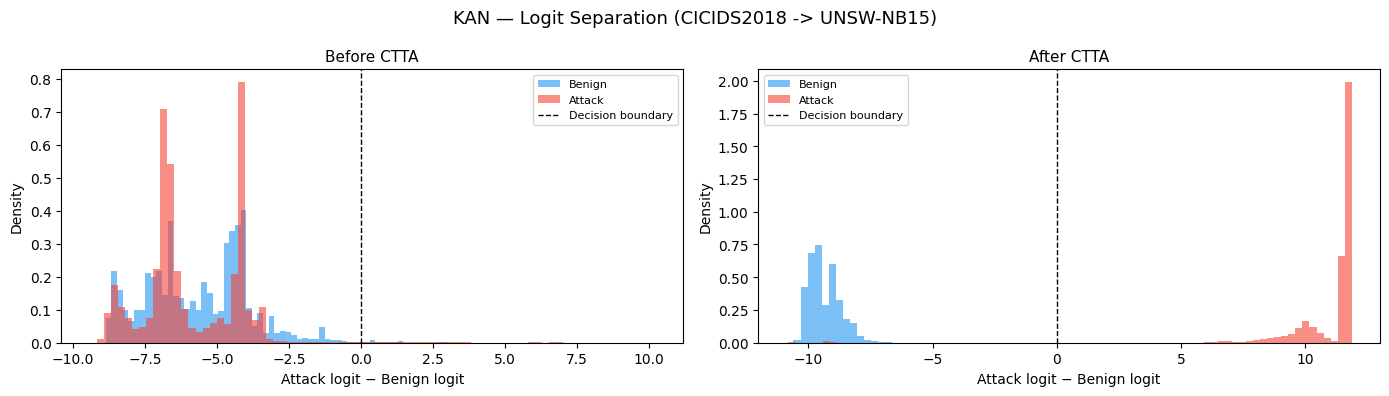

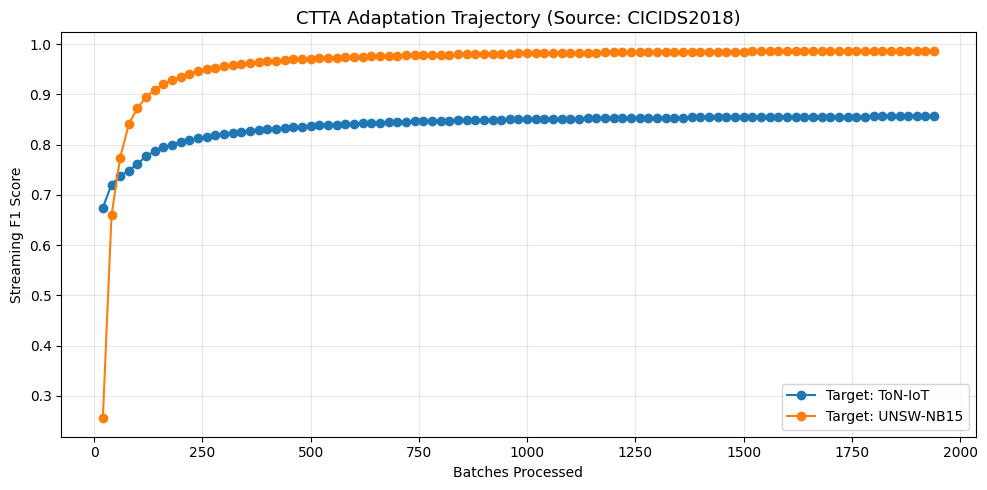

EXPERIMENT | Arch: KAN | Source: ToN-IoT
[Data] Loading seyhed/nf-ton-iot-v3 ...
Using Colab cache for faster access to the 'nf-ton-iot-v3' dataset.
   -> Shape: (1000000, 49) | Attack rate: 38.97%
PHASE 1: SOURCE PRE-TRAINING (ToN-IoT) | KAN
[Model] kan | input_dim=49 | latent_dim=32 | total params=103,810 | trainable params=20610

[Pretrain] Epoch 1/20 | Loss: 0.2508 | Acc: 0.9007
[Pretrain] Epoch 2/20 | Loss: 0.2049 | Acc: 0.9194
[Pretrain] Epoch 3/20 | Loss: 0.1982 | Acc: 0.9231
[Pretrain] Epoch 4/20 | Loss: 0.1936 | Acc: 0.9254
[Pretrain] Epoch 5/20 | Loss: 0.1911 | Acc: 0.9269
[Pretrain] Epoch 6/20 | Loss: 0.1891 | Acc: 0.9288
[Pretrain] Epoch 7/20 | Loss: 0.1854 | Acc: 0.9323
[Pretrain] Epoch 8/20 | Loss: 0.1826 | Acc: 0.9342
[Pretrain] Epoch 9/20 | Loss: 0.1779 | Acc: 0.9364
[Pretrain] Epoch 10/20 | Loss: 0.1740 | Acc: 0.9382
[Pretrain] Epoch 11/20 | Loss: 0.1718 | Acc: 0.9398
[Pretrain] Epoch 12/20 | Loss: 0.1700 | Acc: 0.9408
[Pretrain] Epoch 13/20 | Loss: 0.1698 | Acc: 0.940

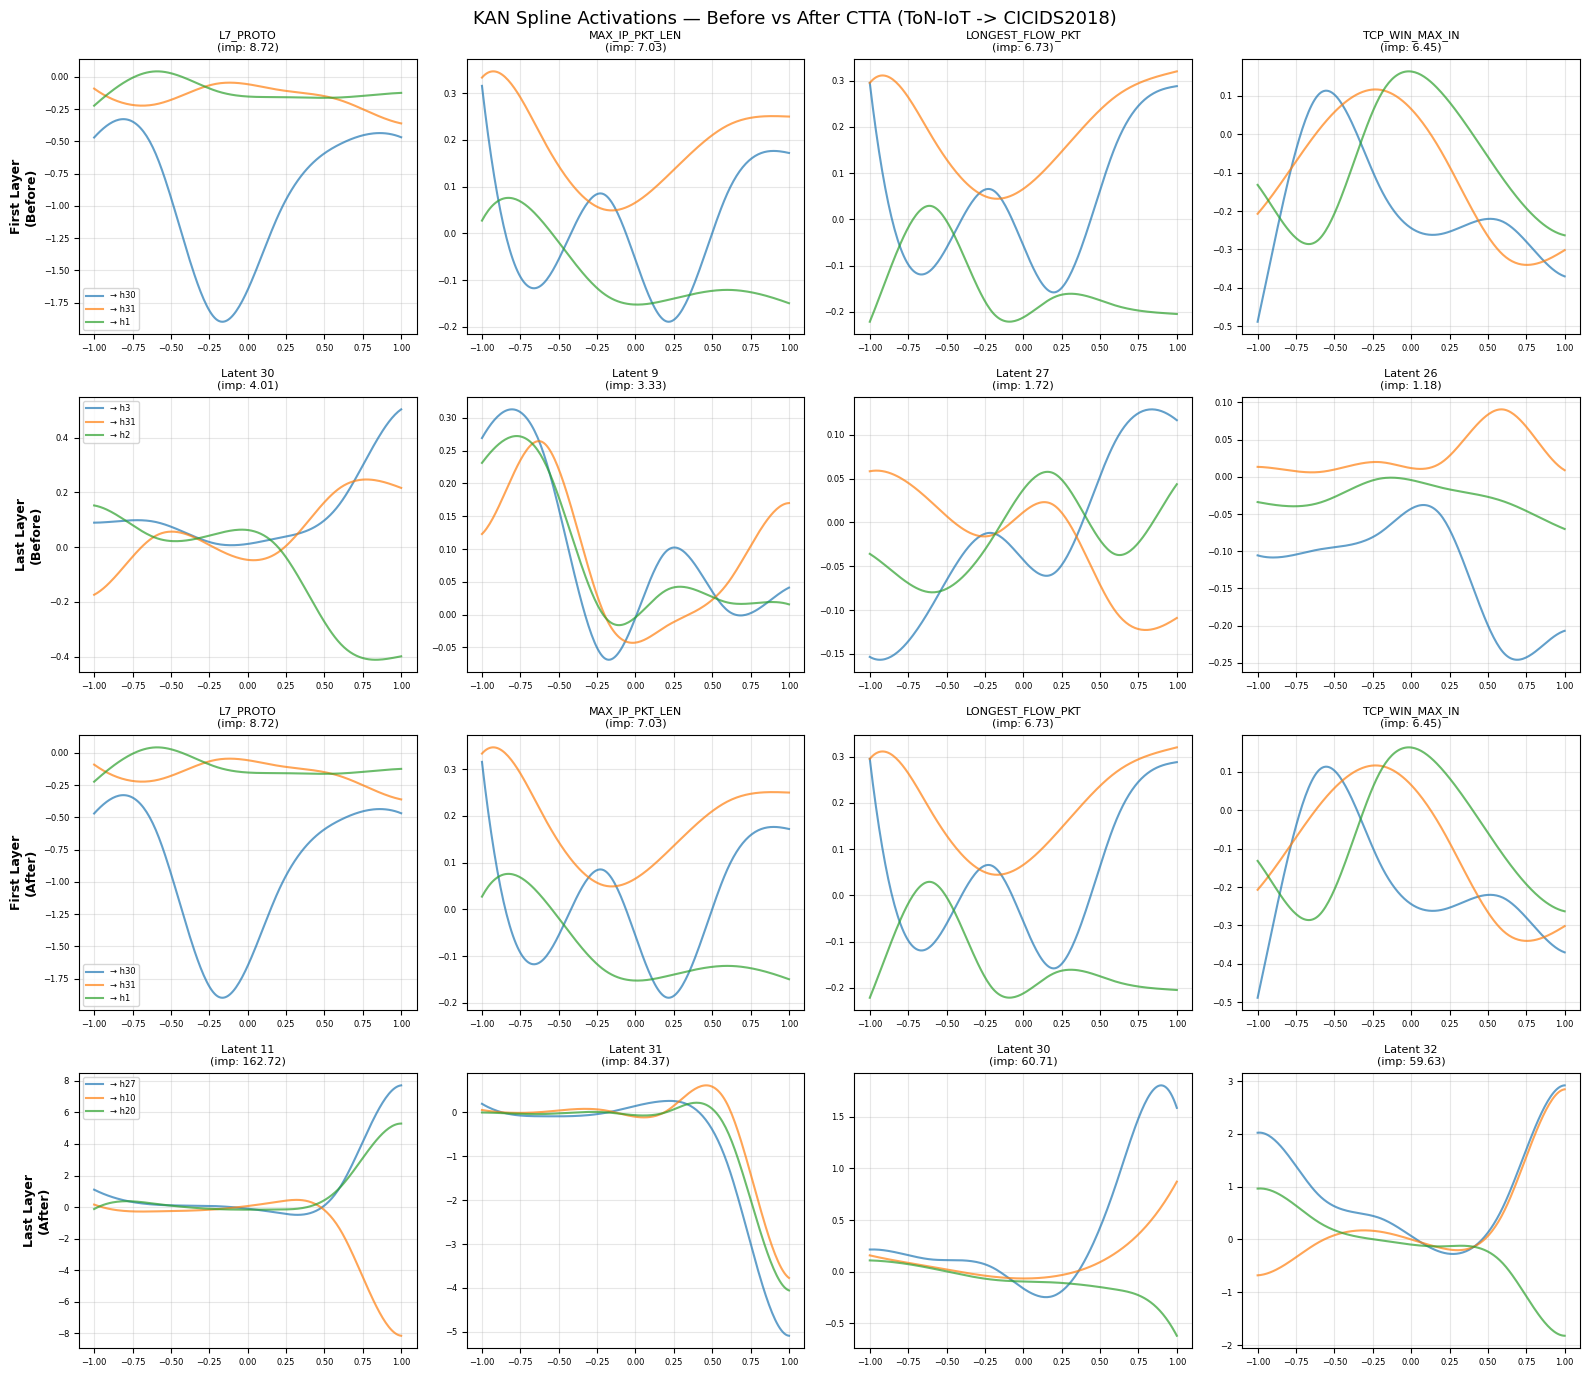

--------------------------------------------------------------------------------

--- [2026-06-06 16:16:06] Executing | Arch: KAN | Source: ToN-IoT -> Target: UNSW-NB15 ---
[Data] Loading seyhed/nf-unsw-nb15-v3 ...
Using Colab cache for faster access to the 'nf-unsw-nb15-v3' dataset.
   -> Shape: (1000000, 49) | Attack rate: 5.44%
   -> Pool: 1000 samples (attack rate: 5.40%) | Stream: 999000 (attack rate: 5.44%)

--- PHASE 2: ZERO-SHOT BASELINE (UNSW-NB15) ---
[Zero-shot UNSW-NB15] F1: 0.5969 | Acc: 0.9632
[Few-shot-only (kan)] F1: 0.0009 | Acc: 0.9456
[KAN Retention] Computing Fisher Information on Source Data...
[KAN Retention] Initialization Complete.
===Type B Ablation===

ABLATION B TARGET: UNSW-NB15
--------------------------------------------------------------------------------
Table 3 — Trainable subset ablation
  Spline-only                          F1 = 0.9887
  Splines + norm                       F1 = 0.9934
  Splines + classifier                 F1 = 0.9898
  Splines + no

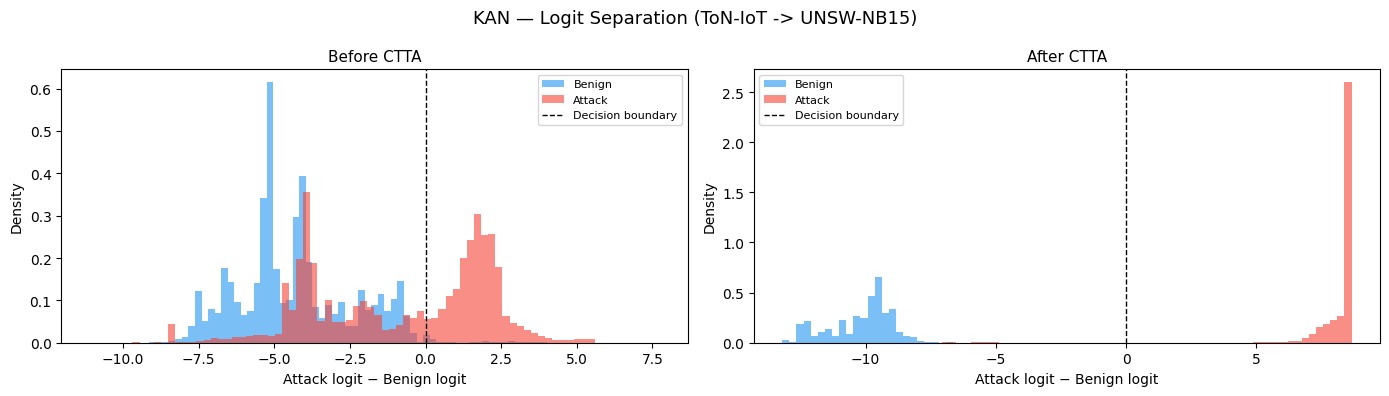

EXPERIMENT | Arch: KAN | Source: UNSW-NB15
[Data] Loading seyhed/nf-unsw-nb15-v3 ...
Using Colab cache for faster access to the 'nf-unsw-nb15-v3' dataset.
   -> Shape: (1000000, 49) | Attack rate: 5.44%
PHASE 1: SOURCE PRE-TRAINING (UNSW-NB15) | KAN
[Model] kan | input_dim=49 | latent_dim=32 | total params=103,810 | trainable params=20610

[Pretrain] Epoch 1/20 | Loss: 0.0079 | Acc: 0.9992
[Pretrain] Epoch 2/20 | Loss: 0.0022 | Acc: 0.9998
[Pretrain] Epoch 3/20 | Loss: 0.0020 | Acc: 0.9998
[Pretrain] Epoch 4/20 | Loss: 0.0019 | Acc: 0.9998
[Pretrain] Epoch 5/20 | Loss: 0.0018 | Acc: 0.9998
[Pretrain] Epoch 6/20 | Loss: 0.0018 | Acc: 0.9998
[Pretrain] Epoch 7/20 | Loss: 0.0017 | Acc: 0.9998
[Pretrain] Epoch 8/20 | Loss: 0.0017 | Acc: 0.9998
[Pretrain] Epoch 9/20 | Loss: 0.0017 | Acc: 0.9998
[Pretrain] Epoch 10/20 | Loss: 0.0016 | Acc: 0.9998
[Pretrain] Epoch 11/20 | Loss: 0.0016 | Acc: 0.9998
[Pretrain] Epoch 12/20 | Loss: 0.0016 | Acc: 0.9998
[Pretrain] Epoch 13/20 | Loss: 0.0016 | Acc

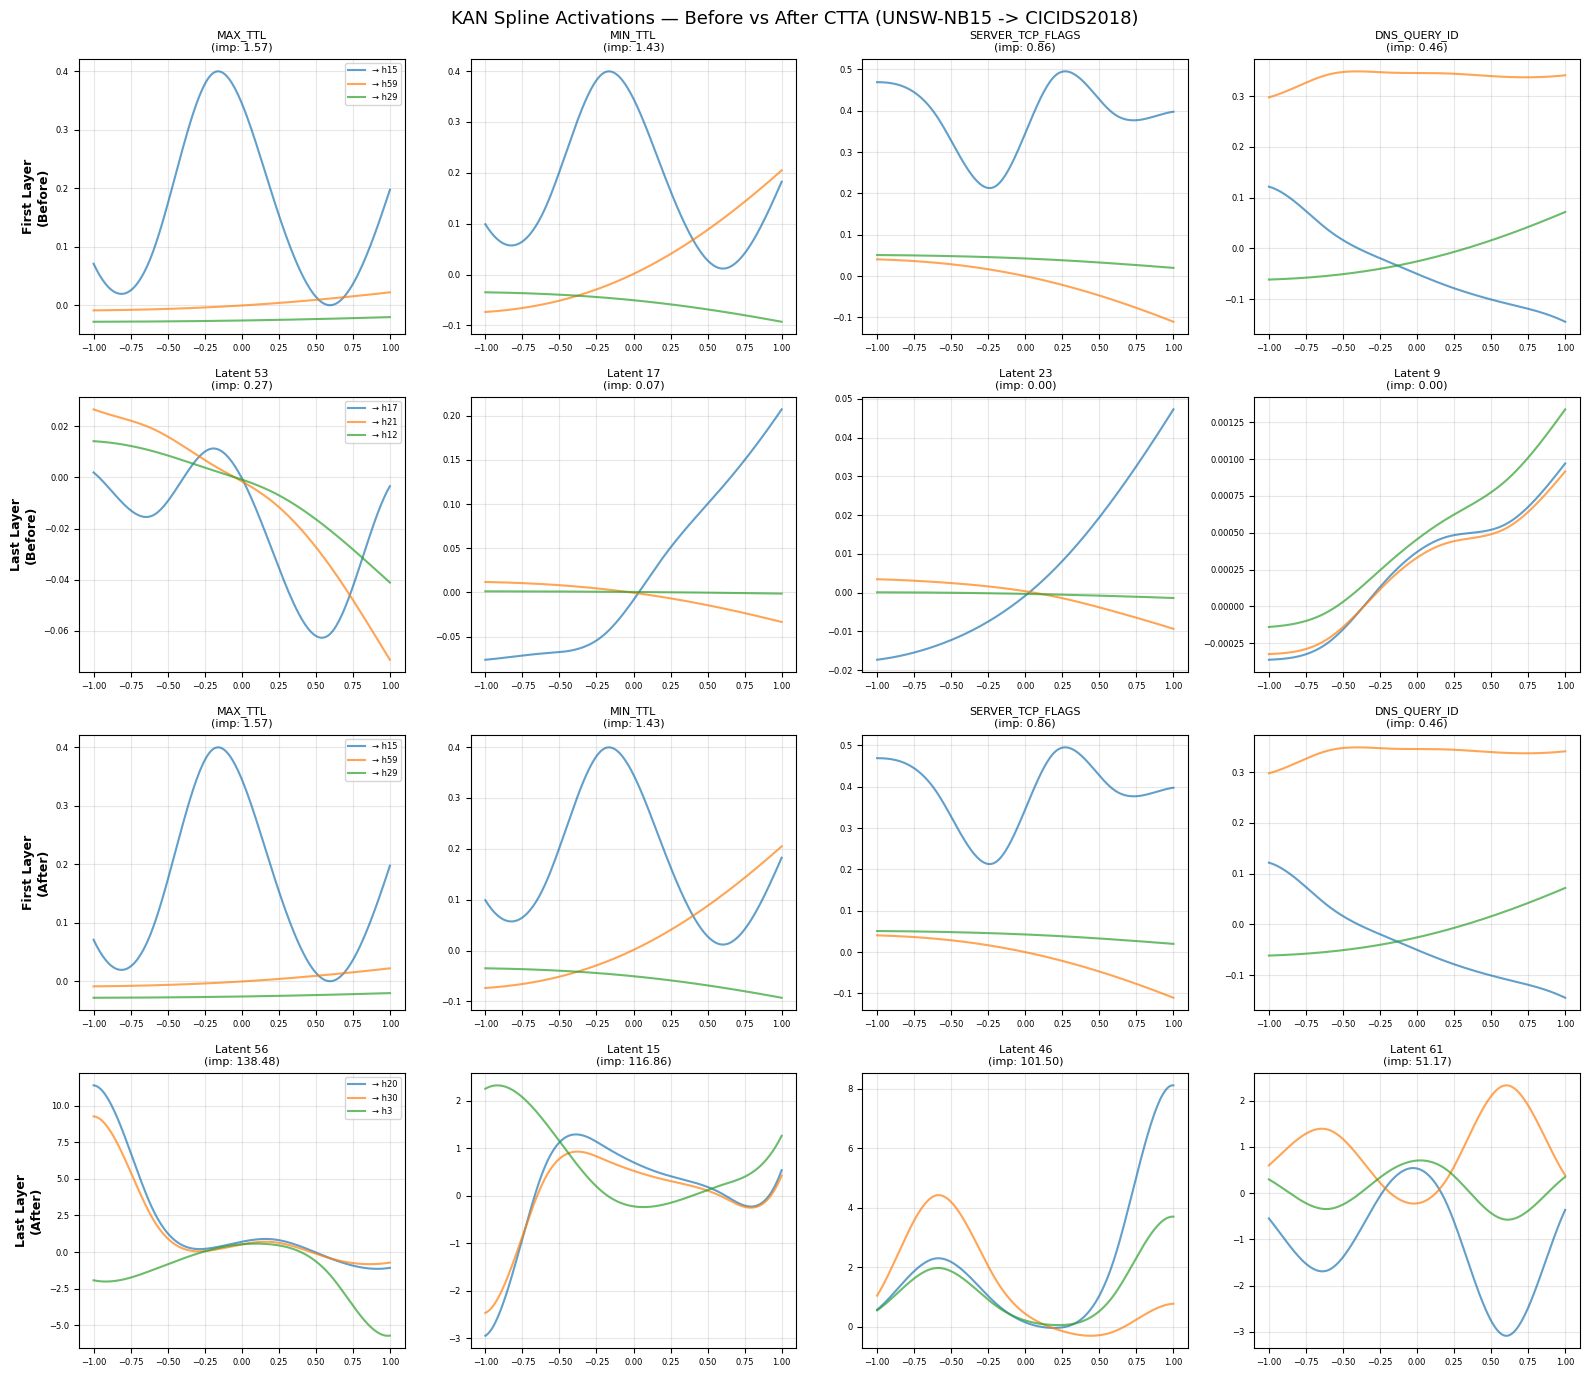

--------------------------------------------------------------------------------

--- [2026-06-06 18:06:35] Executing | Arch: KAN | Source: UNSW-NB15 -> Target: ToN-IoT ---
[Data] Loading seyhed/nf-ton-iot-v3 ...
Using Colab cache for faster access to the 'nf-ton-iot-v3' dataset.
   -> Shape: (1000000, 49) | Attack rate: 38.97%
   -> Pool: 1000 samples (attack rate: 39.00%) | Stream: 999000 (attack rate: 38.97%)

--- PHASE 2: ZERO-SHOT BASELINE (ToN-IoT) ---
[Zero-shot ToN-IoT] F1: 0.7769 | Acc: 0.8447
[Few-shot-only (kan)] F1: 0.7881 | Acc: 0.8536
[KAN Retention] Computing Fisher Information on Source Data...
[KAN Retention] Initialization Complete.
===Type B Ablation===

ABLATION B TARGET: ToN-IoT
--------------------------------------------------------------------------------
Table 3 — Trainable subset ablation
  Spline-only                          F1 = 0.8038
  Splines + norm                       F1 = 0.8050
  Splines + classifier                 F1 = 0.8062
  Splines + norm + cl

,Architecture,Source,Target,Zero-Shot F1,Few-Shot F1,CTTA F1,CTTA Acc,Retention Penalty
0,kan,CICIDS2018,ToN-IoT,0.404121,0.774311,0.856681,0.891890,0.000753
1,kan,CICIDS2018,UNSW-NB15,0.011579,0.000809,0.987117,0.998609,0.000077
2,kan,ToN-IoT,CICIDS2018,0.269706,0.561972,0.926465,0.981360,0.085358
3,kan,ToN-IoT,UNSW-NB15,0.596915,0.000919,0.988852,0.998795,0.184372
4,kan,UNSW-NB15,CICIDS2018,0.266151,0.450970,0.867797,0.966815,0.000007
5,kan,UNSW-NB15,ToN-IoT,0.776896,0.788060,0.802940,0.865314,0.000017
6,cnn,CICIDS2018,ToN-IoT,0.416031,0.777879,0.852252,0.886679,NaN
7,cnn,CICIDS2018,UNSW-NB15,0.128958,0.000074,0.983567,0.998230,NaN
8,cnn,ToN-IoT,CICIDS2018,0.188477,0.000000,0.851608,0.965641,NaN
9,cnn,ToN-IoT,UNSW-NB15,0.054291,0.412925,0.923156,0.992074,NaN


In [117]:


architectures = ['kan', 'cnn', 'tab']
datasets = {
    'CICIDS2018': 'seyhed/nf-cicids2018-v3',
    'ToN-IoT': 'seyhed/nf-ton-iot-v3',
    'UNSW-NB15': 'seyhed/nf-unsw-nb15-v3'
}

results = []

for arch in architectures:
    for src_name, src_path in datasets.items():
        print('=' * 80)
        print(f'EXPERIMENT | Arch: {arch.upper()} | Source: {src_name}')
        print('=' * 80)

        # 1. Load Source
        X_src, y_src, feature_names = load_dataset(src_path, sample_n=SAMPLE_N)
        input_dim = X_src.shape[1]
        loader_src_train, loader_src_test, source_scaler = make_source_loaders(X_src, y_src)
        del X_src, y_src; gc.collect()

        # 2. Pre-train Model
        model = run_phase1_pretraining(arch, src_name, input_dim, loader_src_train, device, PRETRAIN_EPOCHS, LATENT_DIM)

        # Save post-pretrain state
        model_state = {k: v.clone() for k, v in model.state_dict().items()}

        # 3. Determine Targets
        targets = {k: v for k, v in datasets.items() if k != src_name}

        trajectories = {}

        for tgt_name, tgt_path in targets.items():
            print('-' * 80)
            timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            print(f'\n--- [{timestamp}] Executing | Arch: {arch.upper()} | Source: {src_name} -> Target: {tgt_name} ---')

            X_tgt, y_tgt, _ = load_dataset(tgt_path, sample_n=SAMPLE_N)

            # Using source scaler for consistency
            pool_tgt_src_sc, stream_tgt_src_sc = make_target_loaders(X_tgt, y_tgt, external_scaler=source_scaler)
            del X_tgt, y_tgt; gc.collect()

            # Zero-shot Baseline
            model.load_state_dict(model_state)
            zero_shot_f1 = run_phase2_zeroshot(model, stream_tgt_src_sc, tgt_name, device)

            # Few-shot baseline (train from scratch on pool)
            few_shot_f1 = few_shot_baseline(pool_tgt_src_sc, stream_tgt_src_sc, input_dim, arch, device)

            # CTTA
            model.load_state_dict(model_state)

            if arch == 'kan':
                params_to_protect = get_spline_only_params(model) if SPLINE_TRUE else get_trainable_params(model)
                kan_ret = KAN_Retention(model, loader_src_test, device, params_to_protect)

                print('===Type B Ablation===')
                TypeBAblation().run(model, tgt_name, stream_tgt_src_sc, pool_tgt_src_sc)

            preds_ctta, labels_ctta, traj_ctta = run_ctta(
                model, stream_tgt_src_sc, pool_tgt_src_sc, device, spline_only=SPLINE_TRUE
            )

            trajectories[tgt_name] = traj_ctta

            ctta_f1 = f1_score(labels_ctta, preds_ctta, zero_division=0)
            ctta_acc = accuracy_score(labels_ctta, preds_ctta)
            print(f'[CTTA] {tgt_name} - F1: {ctta_f1:.4f} | Acc: {ctta_acc:.4f}')

            retention_val = None
            if arch == 'kan':
                retention_val = kan_ret.penalty().item()
                print(f'[KAN Retention] Penalty: {retention_val:.4f}')
                run_all_visualizations(model_state, model, stream_tgt_src_sc, pool_tgt_src_sc, src_name, tgt_name, device, feature_names)

            # Log results
            results.append({
                'Architecture': arch,
                'Source': src_name,
                'Target': tgt_name,
                'Zero-Shot F1': zero_shot_f1,
                'Few-Shot F1': few_shot_f1,
                'CTTA F1': ctta_f1,
                'CTTA Acc': ctta_acc,
                'Retention Penalty': retention_val
            })

        # Plot adaptation trajectory for KAN from CICIDS2018
        if arch == 'kan' and src_name == 'CICIDS2018':
            plot_adaptation_trajectory(trajectories, src_name)

# Display overall results
results_df = pd.DataFrame(results)
display(results_df)